In [4]:
import pandas as pd

df = pd.read_csv("branded_food.csv", nrows=10)
df.head(10)
# nrows=10 is set because I don't want it to read all the hundreds of thousands of rows
# just to show the first 10 of the dataset, which can add more working RAM and slow down.
# Instead, set a limit to show the first ten lines of rows from the dataset "branded_food".

# Before diving into the first question: "What type of processed and ultra processed foods are
# made or available in the USA?", I selected few columns that are relevant to the question. To
# do this, I will be using Python. The reason why SQL is not used first is because the raw data
# needs to be processed before moving on to querying the data. By Performing data exploratory 
# analysis (EDA) I can check for nulls, inconsistent data, missing data, checking the string 
# consistency of a column and fixing it, moving misplaced data in a column to the right column, 
# deleting duplicates, renaming, checking outliers and skewness, and perform visualizations. 

,fdc_id,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients,not_a_significant_source_of,serving_size,serving_size_unit,household_serving_fulltext,...,data_source,package_weight,modified_date,available_date,market_country,discontinued_date,preparation_state_code,trade_channel,short_description,material_code
0,1105904,Richardson Oilseed Products (US) Limited,NaN,NaN,27000612323,Vegetable Oil,NaN,15.0,ml,1 Tbsp (15 ml),...,GDSN,NaN,2020-10-02,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
1,1105905,CAMPBELL SOUP COMPANY,NaN,NaN,51000198808,"INGREDIENTS: BEEF STOCK, CONTAINS LESS THAN 2%...",NaN,240.0,ml,Amount per serving,...,GDSN,NaN,2020-09-12,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
2,1105906,CAMPBELL SOUP COMPANY,NaN,NaN,51000213273,"INGREDIENTS: CLAM STOCK, POTATOES, CLAMS, CREA...",NaN,440.0,g,PER CONTAINER,...,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
3,1105907,CAMPBELL SOUP COMPANY,NaN,NaN,51000213303,"INGREDIENTS: WATER, CREAM, BROCCOLI, CELERY, V...",NaN,440.0,g,PER CONTAINER,...,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
4,1105908,CAMPBELL SOUP COMPANY,NaN,NaN,51000224637,"INGREDIENTS: CHICKEN STOCK, CONTAINS LESS THAN...",NaN,240.0,ml,Amount per Serving,...,GDSN,NaN,2020-10-03,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
5,1105909,CAMPBELL SOUP COMPANY,NaN,NaN,51000227492,"INGREDIENTS: WATER, PEA BEANS, CARROTS, COOKED...",NaN,412.0,g,PER 1 CAN,...,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
6,1105910,CAMPBELL SOUP COMPANY,NaN,NaN,51000024213,"INGREDIENTS: BEEF STOCK, CONTAINS LESS THAN 2%...",NaN,411.0,g,PER CAN,...,GDSN,NaN,2020-10-03,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
7,1105911,CAMPBELL SOUP COMPANY,NaN,NaN,51000227478,"INGREDIENTS: DICED TOMATOES IN TOMATO JUICE, T...",NaN,120.0,ml,Amount per serving,...,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
8,1105912,CAMPBELL SOUP COMPANY,NaN,NaN,51000058874,"INGREDIENTS: TOMATO PUREE (WATER, TOMATO PASTE...",NaN,120.0,ml,Amount per Serving,...,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
9,1105913,CAMPBELL SOUP COMPANY,NaN,NaN,51000232847,"INGREDIENTS: WATER, TOMATO PUREE (WATER, TOMAT...",NaN,443.0,g,PER SERVING,...,GDSN,NaN,2020-09-26,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN


In [5]:
# After checking the first 10 rows, next is to retrieve the relevant column for the first research question by creating a empty list
# that acts as the basket that I want. Since the first main research question is about "What type of foods/brands are in the USA?", 
# I will first extract the necessary colums first before performing explotory data analysis to check nulls, missing data, duplicates, and inconsistency.
# This ensures performance efficiency.

cols = ["fdc_id", "brand_owner", "brand_name", 
        "branded_food_category", "ingredients", 
        "market_country"]

filtered_chunks = []

for chunk in pd.read_csv("branded_food.csv", chunksize=50000, low_memory=False):
    filtered_chunks.append(chunk[cols])

df = pd.concat(filtered_chunks, ignore_index=True)


In [6]:
# Checking nulls
# Total null count per column
# df.isnull().sum()

# Null percentage per column
df.isnull().sum() / len(df) * 100

# According to the percentage below, the column "brand_name" has about 27.32% of data missing.
# This type of missing data is MNAR or Missing Not At Random. This would probably be likely 
# that generic products, white-label products, and store brands genuinely have no brand name.
# So we cannot do anything about this like filling in the brand names by guessing or predicting it
# which makes absolute no total sense. Additionally, the missingness is not random, because
# those products are unbranded by nature. Since the brand_name is not critical to the research
# it is safe to drop the column. 

fdc_id                    0.000000
brand_owner               0.865156
brand_name               27.327123
branded_food_category     0.533106
ingredients               0.269462
market_country            0.000000
dtype: float64

In [7]:
# Dropping the "brand_name" column

df.drop(columns=["brand_name"], inplace=True) # modifies df directly, no new dataframe created


In [8]:
# Checking the data again
df.columns

Index(['fdc_id', 'brand_owner', 'branded_food_category', 'ingredients',
       'market_country'],
      dtype='object')

In [9]:
# Next, checking the duplicate rows
df.duplicated().sum()

np.int64(0)

In [10]:
# Lastly, checking the if the columns have the correct datatypes
# and fixing string consistency.
df.dtypes

fdc_id                    int64
brand_owner              object
branded_food_category    object
ingredients              object
market_country           object
dtype: object

In [11]:
# Standardizing brand_owner to title case for string consistency
df["brand_owner"] = df["brand_owner"].str.strip().str.title()

In [12]:
# Listing the unique brand_owner
"""
for brand in df["brand_owner"].unique():
    print(brand)
"""

'\nfor brand in df["brand_owner"].unique():\n    print(brand)\n'

In [13]:
# Displaying unique brand owners as a structured table starting from 0
pd.DataFrame(df["brand_owner"].unique(), columns=["brand_owner"]).reset_index(drop=True)

,brand_owner
0,Richardson Oilseed Products (Us) Limited
1,Campbell Soup Company
2,Bush Brothers And Company
3,Pepperidge Farm
4,Welch Foods Inc.
...,...
36284,Dannon Us Llc
36285,Nurture Inc.
36286,Wwf Operating Company Whitewave
36287,"Allied Foods, Inc."


In [14]:
# So far there are more than 30,000 typs of brand owner. Next is to filter the 
# brand owner from the US.

df = df[df["market_country"] == "United States"]

In [15]:
# Next, after we filtered the country set to the US, I want to know
# the unique food categories available.This directly answers the first
# research question: "What type of processed and ultra processed foods 
# are available in the USA?" 
df["branded_food_category"] = df["branded_food_category"].str.strip().str.title()
df["branded_food_category"].value_counts().reset_index()

# We can see that the result shows 350 unique food categories, with Popcorn/Peanuts/Seeds
# & Related Snacks, Candy, Cheese, Ice Cream, and Cookies dominating the 
# top 5. Notably, 4 out of 5 top categories are ultra-processed foods,
# already hinting at the research findings before formal NOVA classification.

,branded_food_category,count
0,"Popcorn, Peanuts, Seeds & Related Snacks",91619
1,Candy,88811
2,Cheese,80758
3,Ice Cream & Frozen Yogurt,60617
4,Cookies & Biscuits,53300
...,...,...
345,Includes Any Products That Can Be Described/Ob...,1
346,"Ready-Made Combination Meal, Frozen Dinner, Fr...",1
347,Packaged Water,1
348,Doodles/ Puffs,1


# Category Based

In [72]:
# Applying the NOVA classification to classify whether the food is 
# processed (Type 3) or ultra-processed (Type 4). NOVA is a food classification 
# system developed by Brazilian researcher Dr. Carlos Augusto Monteiro and his 
# team at the University of São Paulo in 2009. It groups foods not by nutrient 
# content but by the extent and purpose of industrial processing applied to them. 
# NOVA has been adopted by major international health institutions as a framework 
# for dietary guidelines and public health policy, and is supported by extensive 
# research linking ultra-processed food intake to adverse health outcomes such as 
# cardiovascular disease, type 2 diabetes, and mortality — though the system has 
# also faced methodological critique regarding classification consistency 
# (Monteiro et al., 2016; Monteiro et al., 2019; PAHO, 2019; Lane et al., 2024; 
# Braesco et al., 2022).
# 
# NOVA 1 — Unprocessed or minimally processed (fruits, veg, raw meat, eggs)
# NOVA 2 — Processed culinary ingredients (oil, butter, sugar, salt)
# NOVA 3 — Processed foods (canned fish, cheese, cured meats, bread)
# NOVA 4 — Ultra-processed foods (soda, chips, candy, frozen meals)
# 
# For this project, the focus is on NOVA 3 and NOVA 4 since the research 
# question targets processed and ultra-processed foods specifically.

# NOTE: Fix the working

In [16]:
# Sorting all unique categories alphabetically, excluding null values to be safe.
sorted(df["branded_food_category"].dropna().unique())

['Alcohol',
 'Alcoholic Beverages',
 'All Noodles',
 'Amino Acid Supplements',
 'Antioxidant Supplements',
 'Aquatic Invertebrates/Fish/Shellfish/Seafood Combination',
 'Ayurvedic Supplements',
 'Baby/Infant  Foods/Beverages',
 'Baby/Infant – Foods/Beverages',
 'Bacon, Sausages & Ribs',
 'Baking',
 'Baking Accessories',
 'Baking Additives & Extracts',
 'Baking Decorations & Dessert Toppings',
 'Baking/Cooking Mixes (Frozen)',
 'Baking/Cooking Mixes (Perishable)',
 'Baking/Cooking Mixes (Shelf Stable)',
 'Baking/Cooking Mixes/Supplies',
 'Baking/Cooking Mixes/Supplies Variety Packs',
 'Baking/Cooking Supplies (Shelf Stable)',
 'Beef - Prepared/Processed',
 'Beef Sausages - Prepared/Processed',
 'Beer',
 'Berries/Small Fruit',
 'Biscuits/Cookies',
 'Biscuits/Cookies (Frozen)',
 'Biscuits/Cookies (Shelf Stable)',
 'Bread',
 'Bread & Muffin Mixes',
 'Bread (Frozen)',
 'Bread (Shelf Stable)',
 'Bread/Bakery Products Variety Packs',
 'Breads & Buns',
 'Breakfast Drinks',
 'Breakfast Foods',


In [17]:
# I notice some inconsistency and mixed data like descriptions diguised as categories that
# needs to be fixed before moving to vizualizations.

# Replace em dashes with regular
df["branded_food_category"] = df["branded_food_category"].str.replace("–", "-", regex=False)

In [18]:
# Removing the long descriptions
df = df[df["branded_food_category"].str.len() < 60]

In [19]:
# Removing non-food categories
non_food = ["Gardening", "Home Decoration & Supplies", "Kitchen Supplies",
            "Media", "Skin Care Preparations", "Oral Hygiene Products",
            "Childcare", "Other Pet Food", "Health Care", "Miscellanious"]

df = df[~df["branded_food_category"].isin(non_food)]

In [20]:
df["branded_food_category"].nunique()

295

In [21]:
# Viewing the remaining categories to make sure that 
# all the categories are not non-food categories
sorted(df["branded_food_category"].dropna().unique())

# I saw some that are non-food category, duplicates, some have inconsistency.
# I will have to fix this.

['Alcohol',
 'Alcoholic Beverages',
 'All Noodles',
 'Amino Acid Supplements',
 'Antioxidant Supplements',
 'Aquatic Invertebrates/Fish/Shellfish/Seafood Combination',
 'Ayurvedic Supplements',
 'Baby/Infant  Foods/Beverages',
 'Baby/Infant - Foods/Beverages',
 'Bacon, Sausages & Ribs',
 'Baking',
 'Baking Accessories',
 'Baking Additives & Extracts',
 'Baking Decorations & Dessert Toppings',
 'Baking/Cooking Mixes (Frozen)',
 'Baking/Cooking Mixes (Perishable)',
 'Baking/Cooking Mixes (Shelf Stable)',
 'Baking/Cooking Mixes/Supplies',
 'Baking/Cooking Mixes/Supplies Variety Packs',
 'Baking/Cooking Supplies (Shelf Stable)',
 'Beef - Prepared/Processed',
 'Beef Sausages - Prepared/Processed',
 'Beer',
 'Berries/Small Fruit',
 'Biscuits/Cookies',
 'Biscuits/Cookies (Frozen)',
 'Biscuits/Cookies (Shelf Stable)',
 'Bread',
 'Bread & Muffin Mixes',
 'Bread (Frozen)',
 'Bread (Shelf Stable)',
 'Bread/Bakery Products Variety Packs',
 'Breads & Buns',
 'Breakfast Drinks',
 'Breakfast Foods',


In [22]:
# Remove " - " pattern to merge duplicates like "Fish - Prepared/Processed" 
# and "Fish Prepared/Processed" into one
df["branded_food_category"] = df["branded_food_category"].str.replace(" - ", " ", regex=False)

# Clean up any double spaces that might result
df["branded_food_category"] = df["branded_food_category"].str.replace(r"\s+", " ", regex=True).str.strip()

# Check new count
df["branded_food_category"].nunique()

279

In [23]:
# Additional non-food keywords
more_non_food = [
    "vitamin", "mineral", "supplement", "tobacco", 
    "weight control", "water enhancer"
]

mask = df["branded_food_category"].str.lower().str.contains(
    "|".join(more_non_food), na=False
)
df = df[~mask]

df["branded_food_category"].nunique()

262

In [24]:
alcohol = ["Alcohol", "Alcoholic Beverages", "Beer"]
df = df[~df["branded_food_category"].isin(alcohol)]

In [25]:
df["branded_food_category"].nunique()

259

In [26]:
sorted(df["branded_food_category"].dropna().unique())

['All Noodles',
 'Aquatic Invertebrates/Fish/Shellfish/Seafood Combination',
 'Baby/Infant Foods/Beverages',
 'Bacon, Sausages & Ribs',
 'Baking',
 'Baking Accessories',
 'Baking Additives & Extracts',
 'Baking Decorations & Dessert Toppings',
 'Baking/Cooking Mixes (Frozen)',
 'Baking/Cooking Mixes (Perishable)',
 'Baking/Cooking Mixes (Shelf Stable)',
 'Baking/Cooking Mixes/Supplies',
 'Baking/Cooking Mixes/Supplies Variety Packs',
 'Baking/Cooking Supplies (Shelf Stable)',
 'Beef Prepared/Processed',
 'Beef Sausages Prepared/Processed',
 'Berries/Small Fruit',
 'Biscuits/Cookies',
 'Biscuits/Cookies (Frozen)',
 'Biscuits/Cookies (Shelf Stable)',
 'Bread',
 'Bread & Muffin Mixes',
 'Bread (Frozen)',
 'Bread (Shelf Stable)',
 'Bread/Bakery Products Variety Packs',
 'Breads & Buns',
 'Breakfast Drinks',
 'Breakfast Foods',
 'Breakfast Sandwiches, Biscuits & Meals',
 'Butter & Spread',
 'Butter/Butter Substitutes',
 'Cake, Cookie & Cupcake Mixes',
 'Cakes Sweet (Frozen)',
 'Cakes Sweet 

In [27]:
# Remove all dashes entirely and normalize spaces
df["branded_food_category"] = df["branded_food_category"].str.replace("-", "", regex=False)
df["branded_food_category"] = df["branded_food_category"].str.replace(r"\s+", " ", regex=True).str.strip()

# Check new count
df["branded_food_category"].nunique()

259

In [28]:
sorted(df["branded_food_category"].dropna().unique())

['All Noodles',
 'Aquatic Invertebrates/Fish/Shellfish/Seafood Combination',
 'Baby/Infant Foods/Beverages',
 'Bacon, Sausages & Ribs',
 'Baking',
 'Baking Accessories',
 'Baking Additives & Extracts',
 'Baking Decorations & Dessert Toppings',
 'Baking/Cooking Mixes (Frozen)',
 'Baking/Cooking Mixes (Perishable)',
 'Baking/Cooking Mixes (Shelf Stable)',
 'Baking/Cooking Mixes/Supplies',
 'Baking/Cooking Mixes/Supplies Variety Packs',
 'Baking/Cooking Supplies (Shelf Stable)',
 'Beef Prepared/Processed',
 'Beef Sausages Prepared/Processed',
 'Berries/Small Fruit',
 'Biscuits/Cookies',
 'Biscuits/Cookies (Frozen)',
 'Biscuits/Cookies (Shelf Stable)',
 'Bread',
 'Bread & Muffin Mixes',
 'Bread (Frozen)',
 'Bread (Shelf Stable)',
 'Bread/Bakery Products Variety Packs',
 'Breads & Buns',
 'Breakfast Drinks',
 'Breakfast Foods',
 'Breakfast Sandwiches, Biscuits & Meals',
 'Butter & Spread',
 'Butter/Butter Substitutes',
 'Cake, Cookie & Cupcake Mixes',
 'Cakes Sweet (Frozen)',
 'Cakes Sweet 

In [29]:
# NOVA classification
# Define keywords for each NOVA category
# Order matters — more specific rules checked first

def classify_nova(category):
    if pd.isna(category):
        return "Unknown"
    
    cat_lower = category.lower()
    
    # NOVA 1 - Unprocessed or minimally processed
    nova1_keywords = ["unprepared/unprocessed", "berries", "peppers", 
                      "tomatoes", "chickpeas", "herbs & spices", 
                      "herbs/spices"]
    
    # NOVA 2 - Processed culinary ingredients  
    nova2_keywords = ["oils edible", "sugars/sugar", "granulated", "honey", 
                      "vinegars", "syrups & molasses", "vegetable & cooking oils",
                      "flours & corn meal", "grains/flour"]
    
    # NOVA 3 - Processed foods
    nova3_keywords = ["canned", "cheese", "bread", "pickled", "yogurt",
                      "butter", "milk", "cream", "eggs", "nuts/seeds prepared",
                      "fish prepared", "shellfish prepared", "smoked",
                      "fruit prepared", "vegetables prepared", "nut & seed butters"]
    
    # NOVA 4 - Ultra-processed foods (checked last as catch-all for processed packaged foods)
    nova4_keywords = ["candy", "soda", "chips", "cookies", "biscuits", "cakes",
                      "ice cream", "chocolate", "pizza", "sausages", "bacon",
                      "hotdogs", "frozen dinners", "frozen breakfast", "cereal",
                      "snacks", "pastries", "pancakes", "waffles", "desserts",
                      "confection", "muffin", "sweet bakery", "dressings",
                      "ketchup", "gravy", "soup", "pasta dinners", "pepperoni",
                      "salami", "ready to eat", "ready to drink", "mixes",
                      "sport drinks", "powdered drinks", "energy", "gum",
                      "puddings", "gelatin", "jam", "flavored", "doodles",
                      "meal replacement", "chili & stew", "stuffing",
                      "meat substitutes", "fish substitutes", "sauces", 
                      "sweet spreads", "french fries", "burritos", "sandwiches",
                      "sushi", "deli", "pies/pastries"]
    
    # Check in order: NOVA 4 first (most specific), then 3, 2, 1
    if any(kw in cat_lower for kw in nova4_keywords):
        return "NOVA 4 - Ultra-Processed"
    elif any(kw in cat_lower for kw in nova3_keywords):
        return "NOVA 3 - Processed"
    elif any(kw in cat_lower for kw in nova2_keywords):
        return "NOVA 2 - Culinary Ingredient"
    elif any(kw in cat_lower for kw in nova1_keywords):
        return "NOVA 1 - Unprocessed/Minimally Processed"
    else:
        return "Other/Unclassified"

# Apply the classification
df["nova_category"] = df["branded_food_category"].apply(classify_nova)

# Check the distribution
df["nova_category"].value_counts().reset_index()

,nova_category,count
0,NOVA 4 - Ultra-Processed,1076861
1,Other/Unclassified,436055
2,NOVA 3 - Processed,325482
3,NOVA 1 - Unprocessed/Minimally Processed,77038
4,NOVA 2 - Culinary Ingredient,48240


In [1]:
"""
import plotly.express as px

# Prepare data with percentages
nova_dist = df["nova_category"].value_counts().reset_index()
nova_dist.columns = ["nova_category", "count"]
nova_dist["percentage"] = (nova_dist["count"] / nova_dist["count"].sum() * 100).round(1)

# Create custom labels with counts and percentages
nova_dist["label"] = nova_dist["nova_category"] + "<br>" + \
                     nova_dist["count"].astype(str) + " products<br>" + \
                     nova_dist["percentage"].astype(str) + "%"

# Create treemap
fig = px.treemap(
    nova_dist,
    path=["label"],
    values="count",
    color="nova_category",
    color_discrete_map={
        "NOVA 4 - Ultra-Processed": "#d62728",  # Red — warning
        "NOVA 3 - Processed": "#ff7f0e",         # Orange
        "Other/Unclassified": "#7f7f7f",         # Grey
        "NOVA 1 - Unprocessed/Minimally Processed": "#2ca02c",  # Green — healthy
        "NOVA 2 - Culinary Ingredient": "#1f77b4"  # Blue
    },
    title="Distribution of US Branded Food Products by NOVA Classification (2025)<br><sub>Source: USDA FoodData Central, December 2025</sub>"
)

fig.update_layout(
    font=dict(size=14),
    title_font_size=18,
    margin=dict(t=80, l=10, r=10, b=10)
)

fig.show()
"""

'\nimport plotly.express as px\n\n# Prepare data with percentages\nnova_dist = df["nova_category"].value_counts().reset_index()\nnova_dist.columns = ["nova_category", "count"]\nnova_dist["percentage"] = (nova_dist["count"] / nova_dist["count"].sum() * 100).round(1)\n\n# Create custom labels with counts and percentages\nnova_dist["label"] = nova_dist["nova_category"] + "<br>" +                      nova_dist["count"].astype(str) + " products<br>" +                      nova_dist["percentage"].astype(str) + "%"\n\n# Create treemap\nfig = px.treemap(\n    nova_dist,\n    path=["label"],\n    values="count",\n    color="nova_category",\n    color_discrete_map={\n        "NOVA 4 - Ultra-Processed": "#d62728",  # Red — warning\n        "NOVA 3 - Processed": "#ff7f0e",         # Orange\n        "Other/Unclassified": "#7f7f7f",         # Grey\n        "NOVA 1 - Unprocessed/Minimally Processed": "#2ca02c",  # Green — healthy\n        "NOVA 2 - Culinary Ingredient": "#1f77b4"  # Blue\n    },\n  

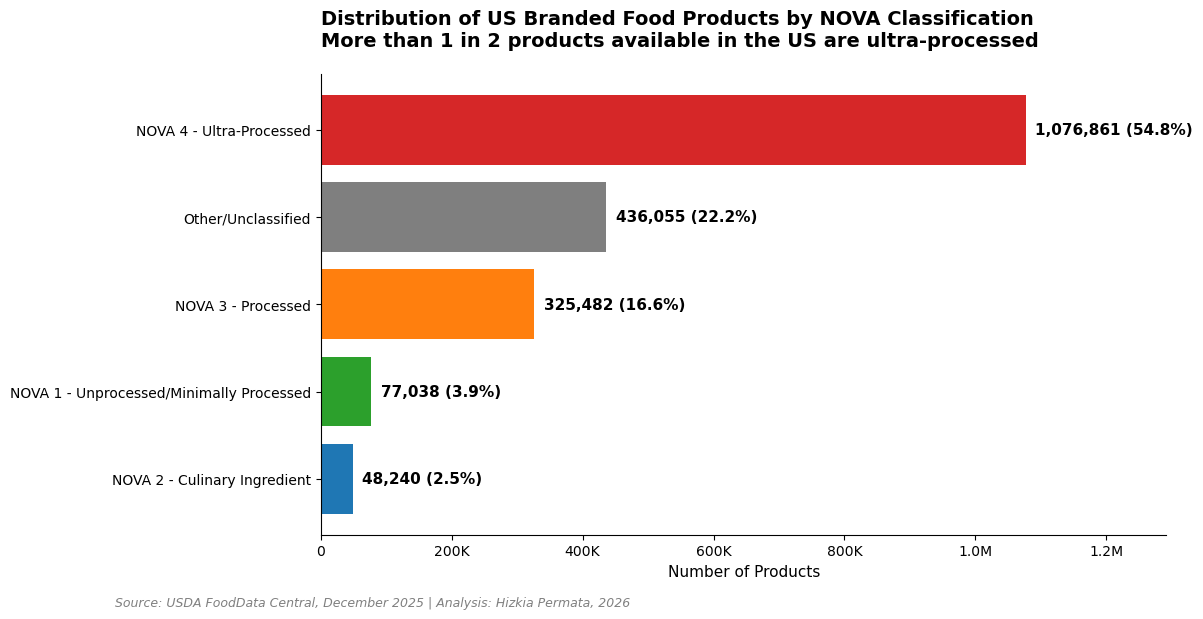

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

nova_dist = df["nova_category"].value_counts().reset_index()
nova_dist.columns = ["nova_category", "count"]
nova_dist["percentage"] = (nova_dist["count"] / nova_dist["count"].sum() * 100).round(1)
nova_dist = nova_dist.sort_values("count")

colors = {
    "NOVA 4 - Ultra-Processed": "#d62728",
    "NOVA 3 - Processed": "#ff7f0e",
    "Other/Unclassified": "#7f7f7f",
    "NOVA 1 - Unprocessed/Minimally Processed": "#2ca02c",
    "NOVA 2 - Culinary Ingredient": "#1f77b4"
}
bar_colors = [colors[cat] for cat in nova_dist["nova_category"]]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(nova_dist["nova_category"], nova_dist["count"], color=bar_colors)

# Add count and percentage labels
for bar, count, pct in zip(bars, nova_dist["count"], nova_dist["percentage"]):
    ax.text(bar.get_width() + 15000, bar.get_y() + bar.get_height()/2, 
            f'{count:,} ({pct}%)', va='center', fontsize=11, fontweight='bold')

ax.set_title("Distribution of US Branded Food Products by NOVA Classification\n"
             "More than 1 in 2 products available in the US are ultra-processed",
             fontsize=14, fontweight='bold', loc='left', pad=20)
ax.set_xlabel("Number of Products", fontsize=11)
ax.set_xlim(0, max(nova_dist["count"]) * 1.2)

# Format x-axis to show K/M instead of scientific notation
def format_millions(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{int(x/1000)}K'
    else:
        return f'{int(x)}'

ax.xaxis.set_major_formatter(mtick.FuncFormatter(format_millions))

# Remove spines for cleanness
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add source caption
fig.text(0.1, -0.02, "Source: USDA FoodData Central, December 2025 | Analysis: Hizkia Permata, 2026",
         fontsize=9, color='grey', style='italic')

plt.tight_layout()
plt.savefig("nova_distribution_overall.png", dpi=300, bbox_inches="tight")  # ← ADDED
plt.show()

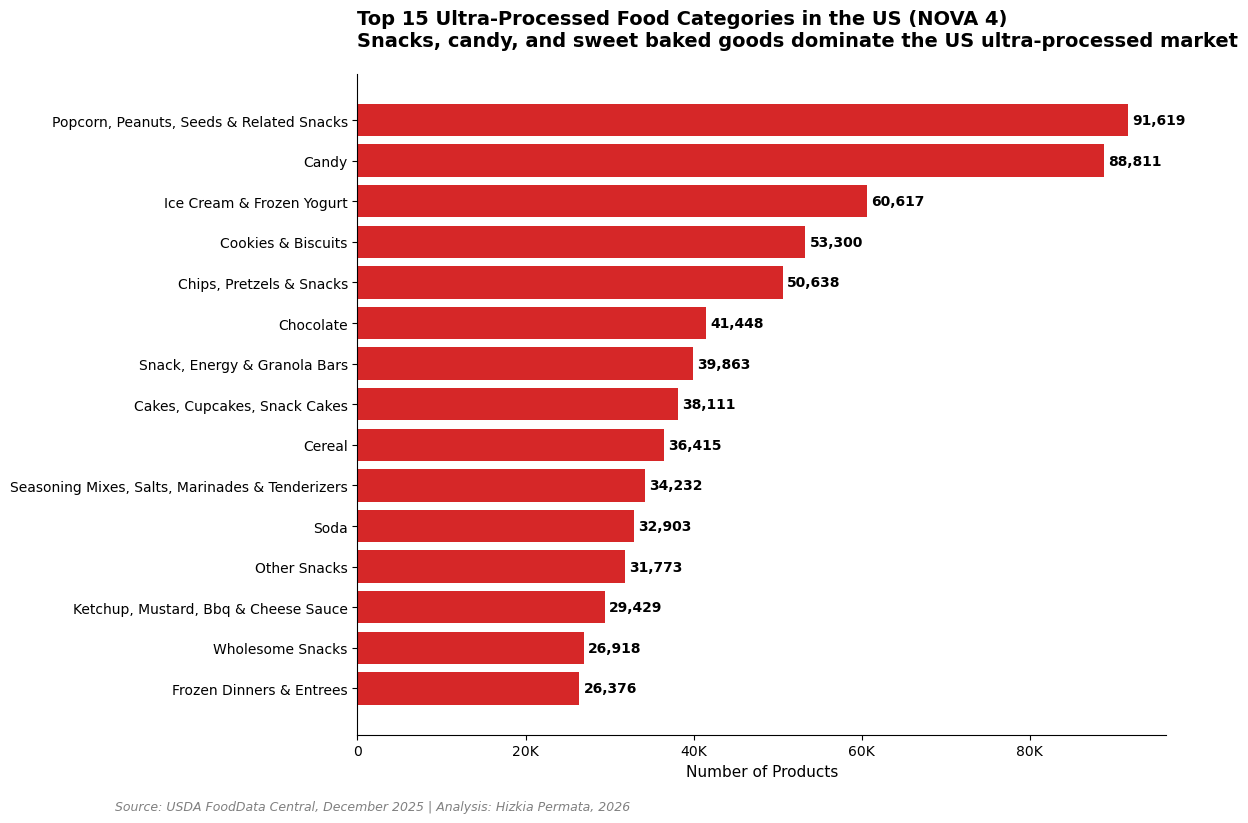

In [34]:
# Filter to only NOVA 4 products
nova4_only = df[df["nova_category"] == "NOVA 4 - Ultra-Processed"]

# Get top 15 food categories within NOVA 4
top_nova4 = nova4_only["branded_food_category"].value_counts().head(15).reset_index()
top_nova4.columns = ["food_category", "count"]
top_nova4 = top_nova4.sort_values("count")

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_nova4["food_category"], top_nova4["count"], color="#d62728")

# Add count labels
for bar, count in zip(bars, top_nova4["count"]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=10, fontweight='bold')

ax.set_title("Top 15 Ultra-Processed Food Categories in the US (NOVA 4)\n"
             "Snacks, candy, and sweet baked goods dominate the US ultra-processed market",
             fontsize=14, fontweight='bold', loc='left', pad=20)
ax.set_xlabel("Number of Products", fontsize=11)

# Format x-axis
ax.xaxis.set_major_formatter(mtick.FuncFormatter(format_millions))

# Remove spines for cleanness
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(0.1, -0.02, "Source: USDA FoodData Central, December 2025 | Analysis: Hizkia Permata, 2026",
         fontsize=9, color='grey', style='italic')

plt.tight_layout()
plt.savefig("nova_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

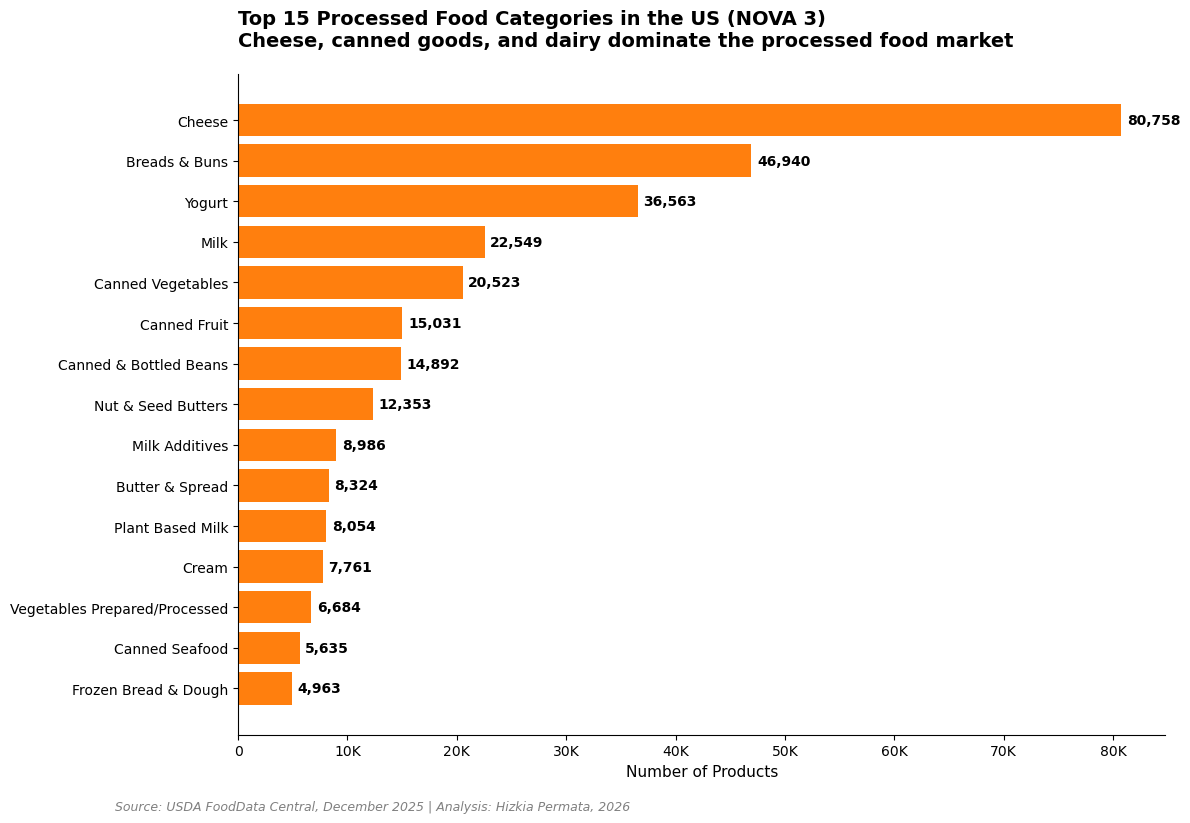

In [32]:
# Filter to only NOVA 3 products
nova3_only = df[df["nova_category"] == "NOVA 3 - Processed"]

# Get top 15 food categories within NOVA 3
top_nova3 = nova3_only["branded_food_category"].value_counts().head(15).reset_index()
top_nova3.columns = ["food_category", "count"]
top_nova3 = top_nova3.sort_values("count")

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_nova3["food_category"], top_nova3["count"], color="#ff7f0e")

for bar, count in zip(bars, top_nova3["count"]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=10, fontweight='bold')

ax.set_title("Top 15 Processed Food Categories in the US (NOVA 3)\n"
             "Cheese, canned goods, and dairy dominate the processed food market",
             fontsize=14, fontweight='bold', loc='left', pad=20)
ax.set_xlabel("Number of Products", fontsize=11)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(format_millions))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(0.1, -0.02, "Source: USDA FoodData Central, December 2025 | Analysis: Hizkia Permata, 2026",
         fontsize=9, color='grey', style='italic')

plt.tight_layout()
plt.savefig("top_nova3_processed_foods.png", dpi=300, bbox_inches="tight")  # ← ADDED
plt.show()

In [35]:
# Saving
# Save the cleaned, NOVA-classified dataset
df.to_csv("branded_food_cleaned_classified.csv", index=False)

# Confirm it saved
print(f"Saved successfully — {len(df):,} rows and {len(df.columns)} columns")

Saved successfully — 1,963,676 rows and 6 columns


In [ ]:
"""
While the NOVA classification system is widely adopted by institutions including the 
FAO (Monteiro et al., 2019) and Pan American Health Organization (PAHO, 2019), 
it has also faced methodological critique regarding consistency of
application (Braesco et al., 2022). This project acknowledges these limitations 
and applies NOVA carefully at the category level rather than ingredient level.
"""

# Ingredients

In [ ]:
# References: 
# 

In [64]:
# Filtering the defining keywords commonly found in ultra-processed food ingredients
# Based on NOVA classification framework (Monteiro et al.)
"""
nova4_keywords = [
    "high fructose corn syrup", "artificial flavor", "artificial colour",
    "artificial color", "natural flavor", "emulsifier", "modified starch",
    "hydrogenated", "maltodextrin", "sodium nitrite", "carrageenan",
    "aspartame", "sucralose", "acesulfame", "xanthan gum", "soy lecithin",
    "polysorbate", "sodium benzoate", "yellow 5", "red 40", "blue 1"
]
"""

'\nnova4_keywords = [\n    "high fructose corn syrup", "artificial flavor", "artificial colour",\n    "artificial color", "natural flavor", "emulsifier", "modified starch",\n    "hydrogenated", "maltodextrin", "sodium nitrite", "carrageenan",\n    "aspartame", "sucralose", "acesulfame", "xanthan gum", "soy lecithin",\n    "polysorbate", "sodium benzoate", "yellow 5", "red 40", "blue 1"\n]\n'

In [65]:
# Function to classify each product into NOVA category
# based on ingredients list
"""
def classify_nova(ingredients):
    if pd.isna(ingredients):
        return "Unknown"
    ingredients_lower = ingredients.lower()
    if any(keyword in ingredients_lower for keyword in nova4_keywords):
        return "NOVA 4 - Ultra-Processed"
    else:
        return "NOVA 3 - Processed"
"""

'\ndef classify_nova(ingredients):\n    if pd.isna(ingredients):\n        return "Unknown"\n    ingredients_lower = ingredients.lower()\n    if any(keyword in ingredients_lower for keyword in nova4_keywords):\n        return "NOVA 4 - Ultra-Processed"\n    else:\n        return "NOVA 3 - Processed"\n'

In [66]:
# Applying NOVA classification to every product
# df["nova_category"] = df["ingredients"].apply(classify_nova)

In [67]:
# Checking how many products fall into each NOVA category
# df["nova_category"].value_counts().reset_index()